# USD & JPY 策略对比分析

## Baseline: max(2,6) = max(02:00, 06:00)

### Max 策略组（vs max(2,6) 基准）:
1. **max(0,2,6)** - 周六 0:00, 2:00, 6:00 取最大值 (3个时点)
2. **max(23~06) hourly** - 周五23:00 + 周六00:00~06:00 每整点 (8个时点)
3. **max(00~06) 30min** - 周六00:00~06:00 每30分钟取最大值 (13个时点)
4. **Extended** - 周五22:00 ~ 周六06:00 每30分钟取最大值 (17个时点)

### Percentile 策略组（vs max(2,6) 基准）:
- **数据源**: 00:00~06:00 每30分钟取一个点 (13个时点)
  - 时点: 00:00, 00:30, 01:00, 01:30, 02:00, 02:30, 03:00, 03:30, 04:00, 04:30, 05:00, 05:30, 06:00
- **P90** - 13个时点的 90th percentile
- **P80** - 13个时点的 80th percentile
- **P70** - 13个时点的 70th percentile
- **P60** - 13个时点的 60th percentile
- **P50** - 13个时点的 50th percentile (中位数)

### BPS 计算公式:
```
BPS = (策略参照价 - max(2,6)) / max(2,6) * 10000
```

**关键:** USD 和 JPY **独立计算**各自的参照价

## 1. 导入库和配置

In [61]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
import warnings
warnings.filterwarnings('ignore')

# Font setup
font_path = r'C:\Windows\Fonts\msyh.ttc'
chinese_font = FontProperties(fname=font_path, size=11)
chinese_font_title = FontProperties(fname=font_path, size=14)
chinese_font_legend = FontProperties(fname=font_path, size=10)

OUTPUT_DIR = r'c:\Users\tencentren\CodeBuddy\FX_SYSTEM\bmad-quant-system\output'

# 每周交易量
USD_WEEKLY = 60_000_000        # 60M USD/week
JPY_WEEKLY = 4_000_000_000     # 4B JPY/week

print("配置完成")

配置完成


## 2. 加载数据

In [62]:
# Load USDCNH and JPYCNH data
all_files = os.listdir(OUTPUT_DIR)
usdcnh_files = [f for f in all_files if 'USDCNH' in f and '1year' in f and f.endswith('.xlsx') and not f.startswith('~$')]
jpycnh_files = [f for f in all_files if 'JPYCNH' in f and '1year' in f and f.endswith('.xlsx') and not f.startswith('~$')]

print(f"Loading USDCNH: {usdcnh_files[0]}")
df_usdcnh = pd.read_excel(os.path.join(OUTPUT_DIR, usdcnh_files[0]))
df_usdcnh['timestamp'] = pd.to_datetime(df_usdcnh['timestamp'])
df_usdcnh.set_index('timestamp', inplace=True)

print(f"Loading JPYCNH: {jpycnh_files[0]}")
df_jpycnh = pd.read_excel(os.path.join(OUTPUT_DIR, jpycnh_files[0]))
df_jpycnh['timestamp'] = pd.to_datetime(df_jpycnh['timestamp'])
df_jpycnh.set_index('timestamp', inplace=True)

# JPYCNH is per 100 JPY, convert to per 1 JPY
df_jpycnh['mid_per_jpy'] = df_jpycnh['mid'] / 100

# Add time columns
for df in [df_usdcnh, df_jpycnh]:
    df['date'] = df.index.date
    df['hour'] = df.index.hour
    df['minute'] = df.index.minute
    df['weekday'] = df.index.dayofweek

print(f"\nUSDCNH 数据范围: {df_usdcnh.index.min()} ~ {df_usdcnh.index.max()}")
print(f"JPYCNH 数据范围: {df_jpycnh.index.min()} ~ {df_jpycnh.index.max()}")

Loading USDCNH: USDCNH_weekend_1year_20260130_195907.xlsx
Loading JPYCNH: JPYCNH_weekend_1year_20260130_200004.xlsx

USDCNH 数据范围: 2025-07-18 05:00:00 ~ 2026-01-30 18:40:00
JPYCNH 数据范围: 2025-07-18 05:00:00 ~ 2026-01-30 18:40:00


## 3. 提取周末数据

In [63]:
# Get Saturday and Friday data
sat_usdcnh = df_usdcnh[df_usdcnh['weekday'] == 5].copy()
fri_usdcnh = df_usdcnh[df_usdcnh['weekday'] == 4].copy()
sat_jpycnh = df_jpycnh[df_jpycnh['weekday'] == 5].copy()
fri_jpycnh = df_jpycnh[df_jpycnh['weekday'] == 4].copy()

sat_dates = sat_usdcnh['date'].unique()
print(f"共 {len(sat_dates)} 个周六的数据")

共 28 个周六的数据


## 4. 计算参照价和 BPS（独立计算 USD 和 JPY）

### Baseline: max(2,6) = max(02:00, 06:00)

### Max 策略:
- **max(0,2,6)** - 周六 0:00, 2:00, 6:00 (3个时点)
- **max(23~06) hourly** - 周五23:00 + 周六00:00~06:00 每整点 (8个时点)
- **max(00~06) 30min** - 周六00:00~06:00 每30分钟 (13个时点)
- **Extended** - 周五22:00~周六06:00 每30分钟 (17个时点)

### Percentile 策略 (基于 00:00~06:00 每30分钟的13个时点):
- P90, P80, P70, P60, P50
- 时点: 00:00, 00:30, 01:00, 01:30, 02:00, 02:30, 03:00, 03:30, 04:00, 04:30, 05:00, 05:30, 06:00

In [64]:
results = []

for sat_date in sat_dates:
    sat_usd = sat_usdcnh[sat_usdcnh['date'] == sat_date]
    sat_jpy = sat_jpycnh[sat_jpycnh['date'] == sat_date]
    fri_date = (pd.Timestamp(sat_date) - pd.Timedelta(days=1)).date()
    fri_usd = fri_usdcnh[fri_usdcnh['date'] == fri_date]
    fri_jpy = fri_jpycnh[fri_jpycnh['date'] == fri_date]
    
    # USDCNH at hour 0, 2, 6
    usd_h0 = sat_usd[(sat_usd['hour'] == 0) & (sat_usd['minute'] == 0)]
    usd_h2 = sat_usd[(sat_usd['hour'] == 2) & (sat_usd['minute'] == 0)]
    usd_h6 = sat_usd[(sat_usd['hour'] == 6) & (sat_usd['minute'] == 0)]
    
    # JPYCNH at hour 0, 2, 6
    jpy_h0 = sat_jpy[(sat_jpy['hour'] == 0) & (sat_jpy['minute'] == 0)]
    jpy_h2 = sat_jpy[(sat_jpy['hour'] == 2) & (sat_jpy['minute'] == 0)]
    jpy_h6 = sat_jpy[(sat_jpy['hour'] == 6) & (sat_jpy['minute'] == 0)]
    
    if len(usd_h0) == 0 or len(usd_h2) == 0 or len(usd_h6) == 0:
        continue
    if len(jpy_h0) == 0 or len(jpy_h2) == 0 or len(jpy_h6) == 0:
        continue
    
    usdcnh_h0 = usd_h0['mid'].values[0]
    usdcnh_h2 = usd_h2['mid'].values[0]
    usdcnh_h6 = usd_h6['mid'].values[0]
    
    jpycnh_h0 = jpy_h0['mid_per_jpy'].values[0]
    jpycnh_h2 = jpy_h2['mid_per_jpy'].values[0]
    jpycnh_h6 = jpy_h6['mid_per_jpy'].values[0]
    
    # ============ max(23~06) hourly: Fri 23:00 + Sat 00:00~06:00 每整点 (8个时点) ============
    usd_hourly_prices = []
    jpy_hourly_prices = []
    
    # Friday 23:00
    usd_fri_23 = fri_usd[(fri_usd['hour'] == 23) & (fri_usd['minute'] == 0)]
    jpy_fri_23 = fri_jpy[(fri_jpy['hour'] == 23) & (fri_jpy['minute'] == 0)]
    if len(usd_fri_23) > 0:
        usd_hourly_prices.append(usd_fri_23['mid'].values[0])
    if len(jpy_fri_23) > 0:
        jpy_hourly_prices.append(jpy_fri_23['mid_per_jpy'].values[0])
    
    # Saturday 00:00 ~ 06:00 每整点
    for h in range(7):  # 0, 1, 2, 3, 4, 5, 6
        usd_data = sat_usd[(sat_usd['hour'] == h) & (sat_usd['minute'] == 0)]
        jpy_data = sat_jpy[(sat_jpy['hour'] == h) & (sat_jpy['minute'] == 0)]
        if len(usd_data) > 0:
            usd_hourly_prices.append(usd_data['mid'].values[0])
        if len(jpy_data) > 0:
            jpy_hourly_prices.append(jpy_data['mid_per_jpy'].values[0])
    
    # ============ max(00~06) 30min: Sat 00:00~06:00 每30分钟 (13个时点) ============
    usd_sat_30min_prices = []
    jpy_sat_30min_prices = []
    
    # Saturday 00:00 ~ 06:00 每30分钟
    for h in range(7):  # 0, 1, 2, 3, 4, 5, 6
        for m in [0, 30]:
            if h == 6 and m == 30:
                continue
            usd_data = sat_usd[(sat_usd['hour'] == h) & (sat_usd['minute'] == m)]
            jpy_data = sat_jpy[(sat_jpy['hour'] == h) & (sat_jpy['minute'] == m)]
            if len(usd_data) > 0:
                usd_sat_30min_prices.append(usd_data['mid'].values[0])
            if len(jpy_data) > 0:
                jpy_sat_30min_prices.append(jpy_data['mid_per_jpy'].values[0])
    
    # ============ Extended: Fri 22:00 ~ Sat 06:00 每30分钟 (17个时点) ============
    usd_extended_prices = []
    jpy_extended_prices = []
    
    # Friday 22:00, 22:30, 23:00, 23:30
    for h in [22, 23]:
        for m in [0, 30]:
            usd_data = fri_usd[(fri_usd['hour'] == h) & (fri_usd['minute'] == m)]
            jpy_data = fri_jpy[(fri_jpy['hour'] == h) & (fri_jpy['minute'] == m)]
            if len(usd_data) > 0:
                usd_extended_prices.append(usd_data['mid'].values[0])
            if len(jpy_data) > 0:
                jpy_extended_prices.append(jpy_data['mid_per_jpy'].values[0])
    
    # Saturday 00:00 ~ 06:00 每30分钟
    for h in range(7):
        for m in [0, 30]:
            if h == 6 and m == 30:
                continue
            usd_data = sat_usd[(sat_usd['hour'] == h) & (sat_usd['minute'] == m)]
            jpy_data = sat_jpy[(sat_jpy['hour'] == h) & (sat_jpy['minute'] == m)]
            if len(usd_data) > 0:
                usd_extended_prices.append(usd_data['mid'].values[0])
            if len(jpy_data) > 0:
                jpy_extended_prices.append(jpy_data['mid_per_jpy'].values[0])
    
    if len(usd_hourly_prices) < 5 or len(jpy_hourly_prices) < 5:
        continue
    if len(usd_sat_30min_prices) < 8 or len(jpy_sat_30min_prices) < 8:
        continue
    if len(usd_extended_prices) < 10 or len(jpy_extended_prices) < 10:
        continue
    
    # ============ USD Reference Prices ============
    usd_ref_max_26 = max(usdcnh_h2, usdcnh_h6)  # baseline
    usd_ref_max_026 = max(usdcnh_h0, usdcnh_h2, usdcnh_h6)
    usd_ref_max_hourly = max(usd_hourly_prices)  # max(23~06) hourly
    usd_ref_max_sat30 = max(usd_sat_30min_prices)  # max(00~06) 30min
    usd_ref_extended = max(usd_extended_prices)
    
    # Percentiles for USD (based on 00~06 30min prices)
    usd_ref_p90 = np.percentile(usd_sat_30min_prices, 90)
    usd_ref_p80 = np.percentile(usd_sat_30min_prices, 80)
    usd_ref_p70 = np.percentile(usd_sat_30min_prices, 70)
    usd_ref_p60 = np.percentile(usd_sat_30min_prices, 60)
    usd_ref_p50 = np.percentile(usd_sat_30min_prices, 50)
    
    # ============ JPY Reference Prices (INDEPENDENT!) ============
    jpy_ref_max_26 = max(jpycnh_h2, jpycnh_h6)  # baseline
    jpy_ref_max_026 = max(jpycnh_h0, jpycnh_h2, jpycnh_h6)
    jpy_ref_max_hourly = max(jpy_hourly_prices)  # max(23~06) hourly
    jpy_ref_max_sat30 = max(jpy_sat_30min_prices)  # max(00~06) 30min
    jpy_ref_extended = max(jpy_extended_prices)
    
    # Percentiles for JPY (based on 00~06 30min prices)
    jpy_ref_p90 = np.percentile(jpy_sat_30min_prices, 90)
    jpy_ref_p80 = np.percentile(jpy_sat_30min_prices, 80)
    jpy_ref_p70 = np.percentile(jpy_sat_30min_prices, 70)
    jpy_ref_p60 = np.percentile(jpy_sat_30min_prices, 60)
    jpy_ref_p50 = np.percentile(jpy_sat_30min_prices, 50)
    
    # ============ BPS Calculation ============
    usd_bps_026 = (usd_ref_max_026 - usd_ref_max_26) / usd_ref_max_26 * 10000
    usd_bps_hourly = (usd_ref_max_hourly - usd_ref_max_26) / usd_ref_max_26 * 10000
    usd_bps_sat30 = (usd_ref_max_sat30 - usd_ref_max_26) / usd_ref_max_26 * 10000
    usd_bps_ext = (usd_ref_extended - usd_ref_max_26) / usd_ref_max_26 * 10000
    usd_bps_p90 = (usd_ref_p90 - usd_ref_max_26) / usd_ref_max_26 * 10000
    usd_bps_p80 = (usd_ref_p80 - usd_ref_max_26) / usd_ref_max_26 * 10000
    usd_bps_p70 = (usd_ref_p70 - usd_ref_max_26) / usd_ref_max_26 * 10000
    usd_bps_p60 = (usd_ref_p60 - usd_ref_max_26) / usd_ref_max_26 * 10000
    usd_bps_p50 = (usd_ref_p50 - usd_ref_max_26) / usd_ref_max_26 * 10000
    
    jpy_bps_026 = (jpy_ref_max_026 - jpy_ref_max_26) / jpy_ref_max_26 * 10000
    jpy_bps_hourly = (jpy_ref_max_hourly - jpy_ref_max_26) / jpy_ref_max_26 * 10000
    jpy_bps_sat30 = (jpy_ref_max_sat30 - jpy_ref_max_26) / jpy_ref_max_26 * 10000
    jpy_bps_ext = (jpy_ref_extended - jpy_ref_max_26) / jpy_ref_max_26 * 10000
    jpy_bps_p90 = (jpy_ref_p90 - jpy_ref_max_26) / jpy_ref_max_26 * 10000
    jpy_bps_p80 = (jpy_ref_p80 - jpy_ref_max_26) / jpy_ref_max_26 * 10000
    jpy_bps_p70 = (jpy_ref_p70 - jpy_ref_max_26) / jpy_ref_max_26 * 10000
    jpy_bps_p60 = (jpy_ref_p60 - jpy_ref_max_26) / jpy_ref_max_26 * 10000
    jpy_bps_p50 = (jpy_ref_p50 - jpy_ref_max_26) / jpy_ref_max_26 * 10000
    
    # ============ PnL Calculation ============
    # USD PnL
    usd_pnl_026 = (usd_ref_max_026 - usd_ref_max_26) * USD_WEEKLY
    usd_pnl_hourly = (usd_ref_max_hourly - usd_ref_max_26) * USD_WEEKLY
    usd_pnl_sat30 = (usd_ref_max_sat30 - usd_ref_max_26) * USD_WEEKLY
    usd_pnl_ext = (usd_ref_extended - usd_ref_max_26) * USD_WEEKLY
    usd_pnl_p90 = (usd_ref_p90 - usd_ref_max_26) * USD_WEEKLY
    usd_pnl_p80 = (usd_ref_p80 - usd_ref_max_26) * USD_WEEKLY
    usd_pnl_p70 = (usd_ref_p70 - usd_ref_max_26) * USD_WEEKLY
    usd_pnl_p60 = (usd_ref_p60 - usd_ref_max_26) * USD_WEEKLY
    usd_pnl_p50 = (usd_ref_p50 - usd_ref_max_26) * USD_WEEKLY
    
    # JPY PnL
    jpy_pnl_026 = (jpy_ref_max_026 - jpy_ref_max_26) * JPY_WEEKLY
    jpy_pnl_hourly = (jpy_ref_max_hourly - jpy_ref_max_26) * JPY_WEEKLY
    jpy_pnl_sat30 = (jpy_ref_max_sat30 - jpy_ref_max_26) * JPY_WEEKLY
    jpy_pnl_ext = (jpy_ref_extended - jpy_ref_max_26) * JPY_WEEKLY
    jpy_pnl_p90 = (jpy_ref_p90 - jpy_ref_max_26) * JPY_WEEKLY
    jpy_pnl_p80 = (jpy_ref_p80 - jpy_ref_max_26) * JPY_WEEKLY
    jpy_pnl_p70 = (jpy_ref_p70 - jpy_ref_max_26) * JPY_WEEKLY
    jpy_pnl_p60 = (jpy_ref_p60 - jpy_ref_max_26) * JPY_WEEKLY
    jpy_pnl_p50 = (jpy_ref_p50 - jpy_ref_max_26) * JPY_WEEKLY
    
    results.append({
        'date': sat_date,
        # USD BPS
        'usd_bps_026': usd_bps_026,
        'usd_bps_hourly': usd_bps_hourly,
        'usd_bps_sat30': usd_bps_sat30,
        'usd_bps_ext': usd_bps_ext,
        'usd_bps_p90': usd_bps_p90,
        'usd_bps_p80': usd_bps_p80,
        'usd_bps_p70': usd_bps_p70,
        'usd_bps_p60': usd_bps_p60,
        'usd_bps_p50': usd_bps_p50,
        # USD PnL
        'usd_pnl_026': usd_pnl_026,
        'usd_pnl_hourly': usd_pnl_hourly,
        'usd_pnl_sat30': usd_pnl_sat30,
        'usd_pnl_ext': usd_pnl_ext,
        'usd_pnl_p90': usd_pnl_p90,
        'usd_pnl_p80': usd_pnl_p80,
        'usd_pnl_p70': usd_pnl_p70,
        'usd_pnl_p60': usd_pnl_p60,
        'usd_pnl_p50': usd_pnl_p50,
        # JPY BPS
        'jpy_bps_026': jpy_bps_026,
        'jpy_bps_hourly': jpy_bps_hourly,
        'jpy_bps_sat30': jpy_bps_sat30,
        'jpy_bps_ext': jpy_bps_ext,
        'jpy_bps_p90': jpy_bps_p90,
        'jpy_bps_p80': jpy_bps_p80,
        'jpy_bps_p70': jpy_bps_p70,
        'jpy_bps_p60': jpy_bps_p60,
        'jpy_bps_p50': jpy_bps_p50,
        # JPY PnL
        'jpy_pnl_026': jpy_pnl_026,
        'jpy_pnl_hourly': jpy_pnl_hourly,
        'jpy_pnl_sat30': jpy_pnl_sat30,
        'jpy_pnl_ext': jpy_pnl_ext,
        'jpy_pnl_p90': jpy_pnl_p90,
        'jpy_pnl_p80': jpy_pnl_p80,
        'jpy_pnl_p70': jpy_pnl_p70,
        'jpy_pnl_p60': jpy_pnl_p60,
        'jpy_pnl_p50': jpy_pnl_p50,
        # Total PnL
        'total_pnl_026': usd_pnl_026 + jpy_pnl_026,
        'total_pnl_hourly': usd_pnl_hourly + jpy_pnl_hourly,
        'total_pnl_sat30': usd_pnl_sat30 + jpy_pnl_sat30,
        'total_pnl_ext': usd_pnl_ext + jpy_pnl_ext,
        'total_pnl_p90': usd_pnl_p90 + jpy_pnl_p90,
        'total_pnl_p80': usd_pnl_p80 + jpy_pnl_p80,
        'total_pnl_p70': usd_pnl_p70 + jpy_pnl_p70,
        'total_pnl_p60': usd_pnl_p60 + jpy_pnl_p60,
        'total_pnl_p50': usd_pnl_p50 + jpy_pnl_p50,
    })

df = pd.DataFrame(results)
print(f"成功处理 {len(df)} 周的数据")
print(f"回测期间: {df['date'].iloc[0]} ~ {df['date'].iloc[-1]}")

成功处理 28 周的数据
回测期间: 2025-07-19 ~ 2026-01-24


## 5. 计算累计 PnL

In [65]:
# Cumulative PnL for all strategies
strategies = ['026', 'hourly', 'sat30', 'ext', 'p90', 'p80', 'p70', 'p60', 'p50']

for strat in strategies:
    df[f'cum_usd_{strat}'] = df[f'usd_pnl_{strat}'].cumsum()
    df[f'cum_jpy_{strat}'] = df[f'jpy_pnl_{strat}'].cumsum()
    df[f'cum_total_{strat}'] = df[f'total_pnl_{strat}'].cumsum()

print("累计 PnL 计算完成")

累计 PnL 计算完成


## 6. 📊 每周平均 BPS 加价统计

In [66]:
print("="*90)
print("每周平均 BPS 加价 vs max(2,6) 基准")
print("="*90)

strategy_names = [
    'max(0,2,6)', 
    'max(23~06) hourly', 
    'max(00~06) 30min',
    'Extended',
    'P90', 'P80', 'P70', 'P60', 'P50'
]

usd_bps_cols = ['usd_bps_026', 'usd_bps_hourly', 'usd_bps_sat30', 'usd_bps_ext',
                'usd_bps_p90', 'usd_bps_p80', 'usd_bps_p70', 'usd_bps_p60', 'usd_bps_p50']
jpy_bps_cols = ['jpy_bps_026', 'jpy_bps_hourly', 'jpy_bps_sat30', 'jpy_bps_ext',
                'jpy_bps_p90', 'jpy_bps_p80', 'jpy_bps_p70', 'jpy_bps_p60', 'jpy_bps_p50']

summary_bps = pd.DataFrame({
    '策略': strategy_names,
    'USD avg bps/周': [df[col].mean() for col in usd_bps_cols],
    'USD median': [df[col].median() for col in usd_bps_cols],
    'JPY avg bps/周': [df[col].mean() for col in jpy_bps_cols],
    'JPY median': [df[col].median() for col in jpy_bps_cols],
})
summary_bps

每周平均 BPS 加价 vs max(2,6) 基准


,策略,USD avg bps/周,USD median,JPY avg bps/周,JPY median
0,"max(0,2,6)",0.752378,0.000000,3.407125,0.000000
1,max(23~06) hourly,1.478037,0.628730,5.857317,4.264747
2,max(00~06) 30min,1.284736,0.628730,4.702918,3.526485
3,Extended,2.276860,1.195985,9.704250,7.970467
4,P90,0.707254,0.356625,2.626586,2.017228
5,P80,0.073328,0.085142,0.254096,0.600416
6,P70,-0.517823,-0.191841,-1.936521,0.020657
7,P60,-0.905848,-0.533934,-3.860096,-1.069724
8,P50,-1.265663,-0.737651,-5.891688,-2.211156


## 7. 💰 累计 PnL 汇总

In [67]:
print("="*90)
print("累计 PnL (Accumulative PnL) vs max(2,6)")
print("="*90)

cum_usd_cols = ['cum_usd_026', 'cum_usd_hourly', 'cum_usd_sat30', 'cum_usd_ext',
                'cum_usd_p90', 'cum_usd_p80', 'cum_usd_p70', 'cum_usd_p60', 'cum_usd_p50']
cum_jpy_cols = ['cum_jpy_026', 'cum_jpy_hourly', 'cum_jpy_sat30', 'cum_jpy_ext',
                'cum_jpy_p90', 'cum_jpy_p80', 'cum_jpy_p70', 'cum_jpy_p60', 'cum_jpy_p50']
cum_total_cols = ['cum_total_026', 'cum_total_hourly', 'cum_total_sat30', 'cum_total_ext',
                  'cum_total_p90', 'cum_total_p80', 'cum_total_p70', 'cum_total_p60', 'cum_total_p50']

summary_pnl = pd.DataFrame({
    '策略': strategy_names,
    'USD累计PnL': [f"{df[col].iloc[-1]:,.0f}" for col in cum_usd_cols],
    'JPY累计PnL': [f"{df[col].iloc[-1]:,.0f}" for col in cum_jpy_cols],
    '合计累计PnL': [f"{df[col].iloc[-1]:,.0f}" for col in cum_total_cols],
})
summary_pnl

累计 PnL (Accumulative PnL) vs max(2,6)


,策略,USD累计PnL,JPY累计PnL,合计累计PnL
0,"max(0,2,6)","891,000","1,804,000","2,695,000"
1,max(23~06) hourly,"1,758,000","3,094,000","4,852,000"
2,max(00~06) 30min,"1,527,000","2,486,000","4,013,000"
3,Extended,"2,715,000","5,072,000","7,787,000"
4,P90,"837,600","1,390,400","2,228,000"
5,P80,"82,800","138,400","221,200"
6,P70,"-621,000","-1,014,800","-1,635,800"
7,P60,"-1,081,800","-2,030,800","-3,112,600"
8,P50,"-1,512,000","-3,104,000","-4,616,000"


## 8. 📈 累计 PnL 图表 - Max策略对比

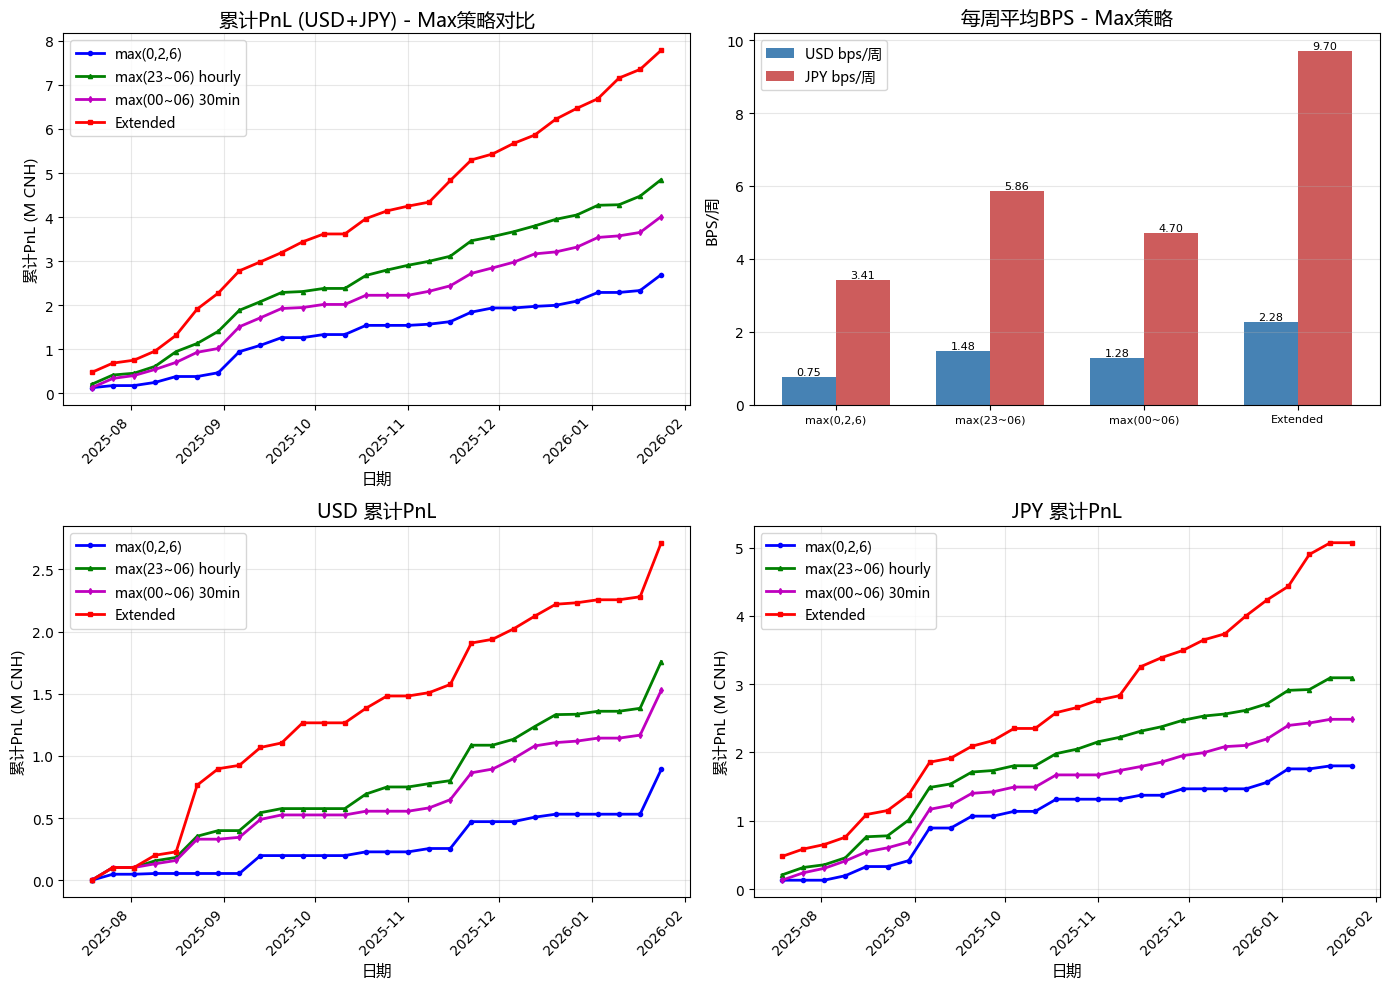

图表已保存至: output/bps_max_strategies.png


In [68]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1: Cumulative Total PnL - Max strategies
ax1 = axes[0, 0]
ax1.plot(df['date'], df['cum_total_026']/1e6, 'b-', linewidth=2, marker='o', markersize=3, label='max(0,2,6)')
ax1.plot(df['date'], df['cum_total_hourly']/1e6, 'g-', linewidth=2, marker='^', markersize=3, label='max(23~06) hourly')
ax1.plot(df['date'], df['cum_total_sat30']/1e6, 'm-', linewidth=2, marker='d', markersize=3, label='max(00~06) 30min')
ax1.plot(df['date'], df['cum_total_ext']/1e6, 'r-', linewidth=2, marker='s', markersize=3, label='Extended')
ax1.set_title('累计PnL (USD+JPY) - Max策略对比', fontproperties=chinese_font_title)
ax1.set_xlabel('日期', fontproperties=chinese_font)
ax1.set_ylabel('累计PnL (M CNH)', fontproperties=chinese_font)
ax1.legend(prop=chinese_font_legend)
ax1.grid(True, alpha=0.3)
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Chart 2: BPS comparison bar chart
ax2 = axes[0, 1]
x_pos = np.arange(4)
width = 0.35
usd_avgs = [df['usd_bps_026'].mean(), df['usd_bps_hourly'].mean(), df['usd_bps_sat30'].mean(), df['usd_bps_ext'].mean()]
jpy_avgs = [df['jpy_bps_026'].mean(), df['jpy_bps_hourly'].mean(), df['jpy_bps_sat30'].mean(), df['jpy_bps_ext'].mean()]
bars1 = ax2.bar(x_pos - width/2, usd_avgs, width, label='USD bps/周', color='steelblue')
bars2 = ax2.bar(x_pos + width/2, jpy_avgs, width, label='JPY bps/周', color='indianred')
ax2.set_title('每周平均BPS - Max策略', fontproperties=chinese_font_title)
ax2.set_ylabel('BPS/周', fontproperties=chinese_font)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(['max(0,2,6)', 'max(23~06)', 'max(00~06)', 'Extended'], fontsize=8)
ax2.legend(prop=chinese_font_legend)
ax2.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars1, usd_avgs):
    ax2.annotate(f'{val:.2f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                 ha='center', va='bottom', fontsize=8)
for bar, val in zip(bars2, jpy_avgs):
    ax2.annotate(f'{val:.2f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                 ha='center', va='bottom', fontsize=8)

# Chart 3: USD Cumulative PnL
ax3 = axes[1, 0]
ax3.plot(df['date'], df['cum_usd_026']/1e6, 'b-', linewidth=2, marker='o', markersize=3, label='max(0,2,6)')
ax3.plot(df['date'], df['cum_usd_hourly']/1e6, 'g-', linewidth=2, marker='^', markersize=3, label='max(23~06) hourly')
ax3.plot(df['date'], df['cum_usd_sat30']/1e6, 'm-', linewidth=2, marker='d', markersize=3, label='max(00~06) 30min')
ax3.plot(df['date'], df['cum_usd_ext']/1e6, 'r-', linewidth=2, marker='s', markersize=3, label='Extended')
ax3.set_title('USD 累计PnL', fontproperties=chinese_font_title)
ax3.set_xlabel('日期', fontproperties=chinese_font)
ax3.set_ylabel('累计PnL (M CNH)', fontproperties=chinese_font)
ax3.legend(prop=chinese_font_legend)
ax3.grid(True, alpha=0.3)
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Chart 4: JPY Cumulative PnL
ax4 = axes[1, 1]
ax4.plot(df['date'], df['cum_jpy_026']/1e6, 'b-', linewidth=2, marker='o', markersize=3, label='max(0,2,6)')
ax4.plot(df['date'], df['cum_jpy_hourly']/1e6, 'g-', linewidth=2, marker='^', markersize=3, label='max(23~06) hourly')
ax4.plot(df['date'], df['cum_jpy_sat30']/1e6, 'm-', linewidth=2, marker='d', markersize=3, label='max(00~06) 30min')
ax4.plot(df['date'], df['cum_jpy_ext']/1e6, 'r-', linewidth=2, marker='s', markersize=3, label='Extended')
ax4.set_title('JPY 累计PnL', fontproperties=chinese_font_title)
ax4.set_xlabel('日期', fontproperties=chinese_font)
ax4.set_ylabel('累计PnL (M CNH)', fontproperties=chinese_font)
ax4.legend(prop=chinese_font_legend)
ax4.grid(True, alpha=0.3)
plt.setp(ax4.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'bps_max_strategies.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"图表已保存至: output/bps_max_strategies.png")

## 9. 📈 累计 PnL 图表 - Percentile策略对比

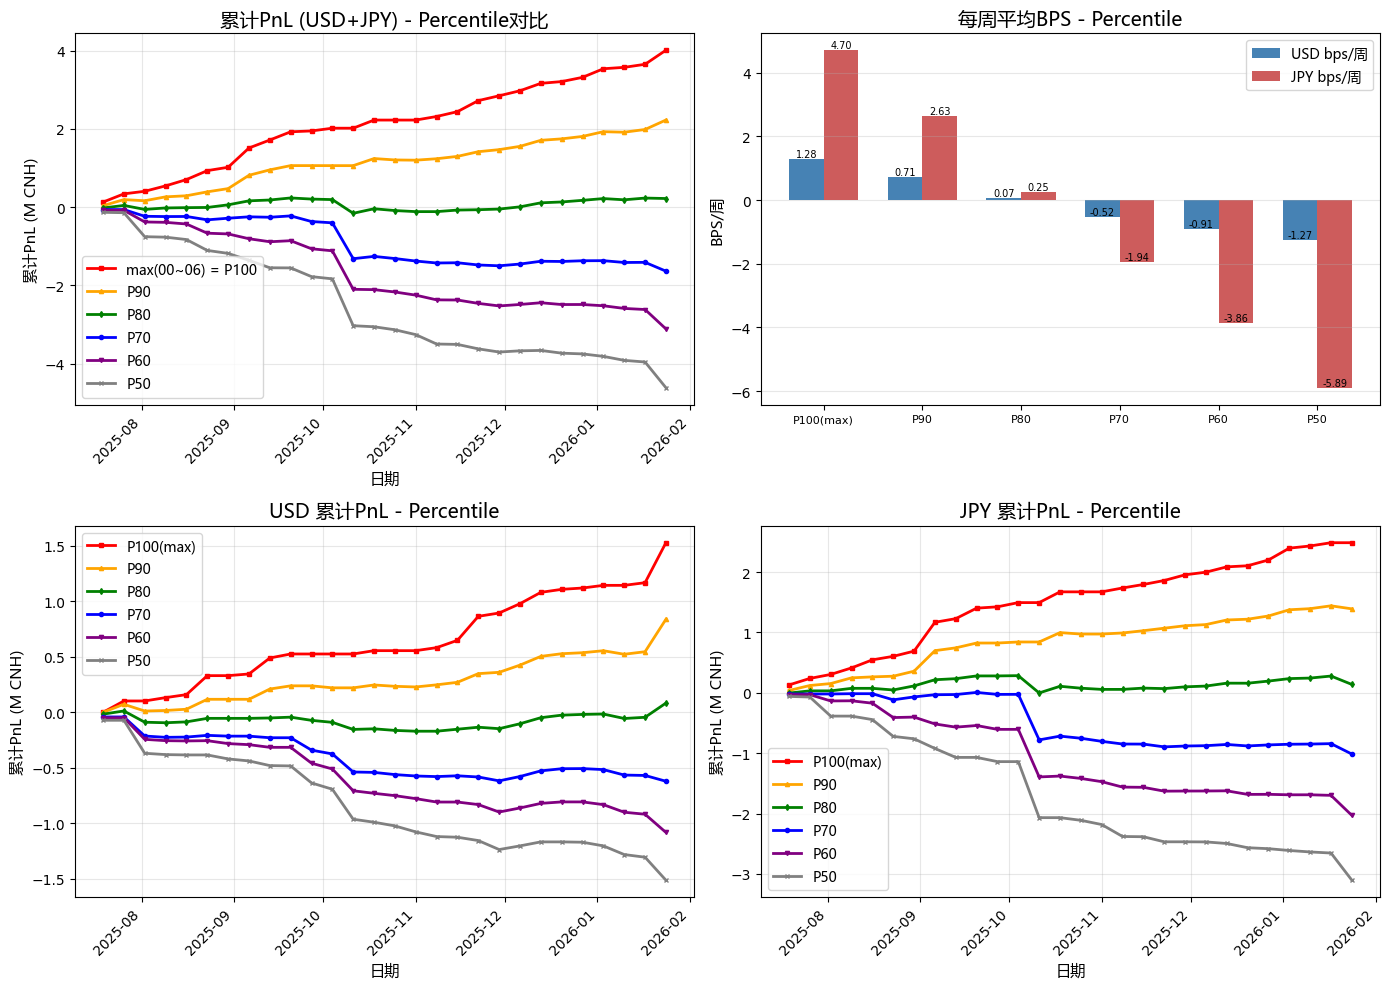

图表已保存至: output/bps_percentile_strategies.png


In [69]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1: Cumulative Total PnL - Percentile strategies
ax1 = axes[0, 0]
ax1.plot(df['date'], df['cum_total_sat30']/1e6, 'r-', linewidth=2, marker='s', markersize=3, label='max(00~06) = P100')
ax1.plot(df['date'], df['cum_total_p90']/1e6, 'orange', linewidth=2, marker='^', markersize=3, label='P90')
ax1.plot(df['date'], df['cum_total_p80']/1e6, 'g-', linewidth=2, marker='d', markersize=3, label='P80')
ax1.plot(df['date'], df['cum_total_p70']/1e6, 'b-', linewidth=2, marker='o', markersize=3, label='P70')
ax1.plot(df['date'], df['cum_total_p60']/1e6, 'purple', linewidth=2, marker='v', markersize=3, label='P60')
ax1.plot(df['date'], df['cum_total_p50']/1e6, 'gray', linewidth=2, marker='x', markersize=3, label='P50')
ax1.set_title('累计PnL (USD+JPY) - Percentile对比', fontproperties=chinese_font_title)
ax1.set_xlabel('日期', fontproperties=chinese_font)
ax1.set_ylabel('累计PnL (M CNH)', fontproperties=chinese_font)
ax1.legend(prop=chinese_font_legend)
ax1.grid(True, alpha=0.3)
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Chart 2: BPS comparison bar chart - Percentiles
ax2 = axes[0, 1]
x_pos = np.arange(6)
width = 0.35
usd_avgs = [df['usd_bps_sat30'].mean(), df['usd_bps_p90'].mean(), df['usd_bps_p80'].mean(), 
            df['usd_bps_p70'].mean(), df['usd_bps_p60'].mean(), df['usd_bps_p50'].mean()]
jpy_avgs = [df['jpy_bps_sat30'].mean(), df['jpy_bps_p90'].mean(), df['jpy_bps_p80'].mean(),
            df['jpy_bps_p70'].mean(), df['jpy_bps_p60'].mean(), df['jpy_bps_p50'].mean()]
bars1 = ax2.bar(x_pos - width/2, usd_avgs, width, label='USD bps/周', color='steelblue')
bars2 = ax2.bar(x_pos + width/2, jpy_avgs, width, label='JPY bps/周', color='indianred')
ax2.set_title('每周平均BPS - Percentile', fontproperties=chinese_font_title)
ax2.set_ylabel('BPS/周', fontproperties=chinese_font)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(['P100(max)', 'P90', 'P80', 'P70', 'P60', 'P50'], fontsize=8)
ax2.legend(prop=chinese_font_legend)
ax2.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars1, usd_avgs):
    ax2.annotate(f'{val:.2f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                 ha='center', va='bottom', fontsize=7)
for bar, val in zip(bars2, jpy_avgs):
    ax2.annotate(f'{val:.2f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                 ha='center', va='bottom', fontsize=7)

# Chart 3: USD Cumulative PnL - Percentiles
ax3 = axes[1, 0]
ax3.plot(df['date'], df['cum_usd_sat30']/1e6, 'r-', linewidth=2, marker='s', markersize=3, label='P100(max)')
ax3.plot(df['date'], df['cum_usd_p90']/1e6, 'orange', linewidth=2, marker='^', markersize=3, label='P90')
ax3.plot(df['date'], df['cum_usd_p80']/1e6, 'g-', linewidth=2, marker='d', markersize=3, label='P80')
ax3.plot(df['date'], df['cum_usd_p70']/1e6, 'b-', linewidth=2, marker='o', markersize=3, label='P70')
ax3.plot(df['date'], df['cum_usd_p60']/1e6, 'purple', linewidth=2, marker='v', markersize=3, label='P60')
ax3.plot(df['date'], df['cum_usd_p50']/1e6, 'gray', linewidth=2, marker='x', markersize=3, label='P50')
ax3.set_title('USD 累计PnL - Percentile', fontproperties=chinese_font_title)
ax3.set_xlabel('日期', fontproperties=chinese_font)
ax3.set_ylabel('累计PnL (M CNH)', fontproperties=chinese_font)
ax3.legend(prop=chinese_font_legend)
ax3.grid(True, alpha=0.3)
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Chart 4: JPY Cumulative PnL - Percentiles
ax4 = axes[1, 1]
ax4.plot(df['date'], df['cum_jpy_sat30']/1e6, 'r-', linewidth=2, marker='s', markersize=3, label='P100(max)')
ax4.plot(df['date'], df['cum_jpy_p90']/1e6, 'orange', linewidth=2, marker='^', markersize=3, label='P90')
ax4.plot(df['date'], df['cum_jpy_p80']/1e6, 'g-', linewidth=2, marker='d', markersize=3, label='P80')
ax4.plot(df['date'], df['cum_jpy_p70']/1e6, 'b-', linewidth=2, marker='o', markersize=3, label='P70')
ax4.plot(df['date'], df['cum_jpy_p60']/1e6, 'purple', linewidth=2, marker='v', markersize=3, label='P60')
ax4.plot(df['date'], df['cum_jpy_p50']/1e6, 'gray', linewidth=2, marker='x', markersize=3, label='P50')
ax4.set_title('JPY 累计PnL - Percentile', fontproperties=chinese_font_title)
ax4.set_xlabel('日期', fontproperties=chinese_font)
ax4.set_ylabel('累计PnL (M CNH)', fontproperties=chinese_font)
ax4.legend(prop=chinese_font_legend)
ax4.grid(True, alpha=0.3)
plt.setp(ax4.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'bps_percentile_strategies.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"图表已保存至: output/bps_percentile_strategies.png")

## 10. 🏆 总结

In [70]:
print("="*90)
print("总结: 所有策略 vs max(2,6) 基准")
print("="*90)
print(f"\n回测期间: {df['date'].iloc[0]} ~ {df['date'].iloc[-1]} ({len(df)} 周)")

print("\n" + "="*90)
print("每周平均 BPS 对比")
print("="*90)
print(f"{'策略':<25} {'USD bps/周':>12} {'JPY bps/周':>12}")
print("-"*50)

strat_map = [
    ('max(0,2,6)', '026'),
    ('max(23~06) hourly', 'hourly'),
    ('max(00~06) 30min', 'sat30'),
    ('Extended (22~06)', 'ext'),
    ('P90', 'p90'),
    ('P80', 'p80'),
    ('P70', 'p70'),
    ('P60', 'p60'),
    ('P50', 'p50'),
]

for name, key in strat_map:
    print(f"{name:<25} {df[f'usd_bps_{key}'].mean():>12.2f} {df[f'jpy_bps_{key}'].mean():>12.2f}")

print("\n" + "="*90)
print("累计 PnL 对比")
print("="*90)
print(f"{'策略':<25} {'USD (CNH)':>15} {'JPY (CNH)':>15} {'合计 (CNH)':>15}")
print("-"*70)

for name, key in strat_map:
    print(f"{name:<25} {df[f'cum_usd_{key}'].iloc[-1]:>15,.0f} {df[f'cum_jpy_{key}'].iloc[-1]:>15,.0f} {df[f'cum_total_{key}'].iloc[-1]:>15,.0f}")

# 年化收益
weeks = len(df)
print("\n" + "="*90)
print("年化收益")
print("="*90)
for name, key in strat_map:
    annual = df[f'cum_total_{key}'].iloc[-1] / weeks * 52
    print(f"{name:<25} {annual:>15,.0f} CNH/年")

总结: 所有策略 vs max(2,6) 基准

回测期间: 2025-07-19 ~ 2026-01-24 (28 周)

每周平均 BPS 对比
策略                           USD bps/周    JPY bps/周
--------------------------------------------------
max(0,2,6)                        0.75         3.41
max(23~06) hourly                 1.48         5.86
max(00~06) 30min                  1.28         4.70
Extended (22~06)                  2.28         9.70
P90                               0.71         2.63
P80                               0.07         0.25
P70                              -0.52        -1.94
P60                              -0.91        -3.86
P50                              -1.27        -5.89

累计 PnL 对比
策略                              USD (CNH)       JPY (CNH)        合计 (CNH)
----------------------------------------------------------------------
max(0,2,6)                        891,000       1,804,000       2,695,000
max(23~06) hourly               1,758,000       3,094,000       4,852,000
max(00~06) 30min                1,527,000       2,

## 11. 📋 每周明细数据

In [71]:
# Display weekly details - BPS
print("=" * 80)
print("每周 BPS 明细")
print("=" * 80)
detail_bps = ['date', 
              'usd_bps_026', 'usd_bps_sat30', 'usd_bps_p90', 'usd_bps_p80', 'usd_bps_p70',
              'jpy_bps_026', 'jpy_bps_sat30', 'jpy_bps_p90', 'jpy_bps_p80', 'jpy_bps_p70']
df[detail_bps].round(2)

每周 BPS 明细


,date,usd_bps_026,usd_bps_sat30,usd_bps_p90,usd_bps_p80,usd_bps_p70,jpy_bps_026,jpy_bps_sat30,jpy_bps_p90,jpy_bps_p80,jpy_bps_p70
0,2025-07-19,0.00,0.00,0.00,-0.39,-0.97,6.73,6.73,1.99,-0.21,-1.01
1,2025-07-26,1.12,2.37,1.67,0.67,0.00,0.00,5.56,4.24,1.85,0.00
2,2025-08-02,0.00,0.00,-1.40,-2.35,-3.97,0.00,3.38,1.64,0.00,0.00
3,2025-08-09,0.14,0.70,0.11,-0.11,-0.28,3.39,5.55,4.87,2.16,0.25
4,2025-08-16,0.00,0.63,0.26,0.18,0.06,6.86,6.86,0.82,0.00,0.00
5,2025-08-23,0.00,3.97,2.08,0.74,0.36,0.00,2.97,0.57,-1.39,-5.19
6,2025-08-30,0.00,0.00,0.00,0.00,-0.17,4.44,4.44,4.27,3.49,2.50
7,2025-09-06,0.00,0.35,0.00,0.00,0.00,24.70,24.70,17.59,5.27,1.86
8,2025-09-13,3.37,3.37,2.16,0.08,-0.34,0.00,3.11,2.40,0.91,0.17
9,2025-09-20,0.00,0.84,0.67,0.17,0.00,9.04,9.04,4.16,2.37,1.81


## 12. 保存数据到 Excel

In [72]:
df.to_excel(os.path.join(OUTPUT_DIR, 'bps_all_strategies.xlsx'), index=False)
print(f"数据已保存至: output/bps_all_strategies.xlsx")

数据已保存至: output/bps_all_strategies.xlsx
